# Chapter 12: Statistical Visualization with Seaborn

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. This notebook uses two datasets:

- `bean_there_sales.csv`: daily sales per store and product (Jan to Mar 2026)
- `ch12_bean_there_orders.csv`: a sample of 3,000 individual receipts with
  the customer's one-tap rating

Each chart cell ends with a `plt.savefig(...)` line that writes the PNG used
in the book into `../figures/`. You can delete those lines in your own work.

## 12.1 Setting up

`sns.set_theme()` switches on Seaborn's look; `style="whitegrid"` adds a light grid.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 80)
sns.set_theme(style="whitegrid")

In [2]:
# Folder for the PNG files used in the book (created if missing)
from pathlib import Path
FIG = Path("../figures")
FIG.mkdir(exist_ok=True)

## 12.2 Meet the receipts data

One row per order: a sample of 3,000 receipts with wait time and the customer's 1 to 5 rating.

In [3]:
sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
orders = pd.read_csv("../data/ch12_bean_there_orders.csv",
                     parse_dates=["date"])
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   order_id     3000 non-null   str           
 1   date         3000 non-null   datetime64[us]
 2   hour         3000 non-null   int64         
 3   day_type     3000 non-null   str           
 4   store        3000 non-null   str           
 5   customer     3000 non-null   str           
 6   payment      3000 non-null   str           
 7   items        3000 non-null   int64         
 8   order_total  3000 non-null   float64       
 9   wait_min     3000 non-null   float64       
 10  rating       3000 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(5)
memory usage: 257.9 KB


In [4]:
orders.iloc[:5, 1:]

,date,hour,day_type,store,customer,payment,items,order_total,wait_min,rating
0,2026-01-01,8,Weekday,Downtown,Walk-in,Card,1,4.25,5.9,2
1,2026-01-01,8,Weekday,Downtown,Loyalty,App,1,2.95,6.6,4
2,2026-01-01,8,Weekday,Riverside,Loyalty,App,3,10.40,8.1,3
3,2026-01-01,8,Weekday,Riverside,Walk-in,Card,3,11.70,3.7,3
4,2026-01-01,8,Weekday,University,Loyalty,App,4,16.75,5.0,3


## 12.3 Distributions

### Histograms

Notice the gap between \$4.75 (the dearest single item) and \$5.90 (the cheapest pair of items).

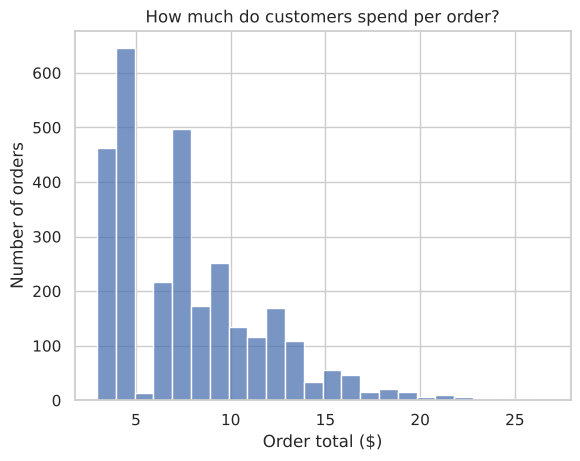

In [5]:
sns.histplot(data=orders, x="order_total", binwidth=1)
plt.title("How much do customers spend per order?")
plt.xlabel("Order total ($)")
plt.ylabel("Number of orders")
plt.savefig(FIG / "ch12-hist-order-total.png", dpi=150, bbox_inches="tight")
plt.show()

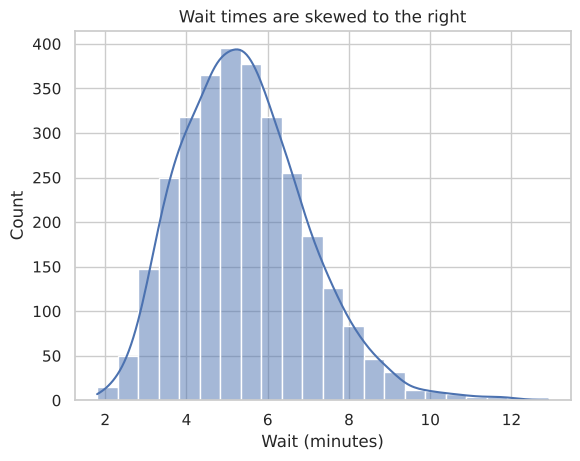

In [6]:
sns.histplot(data=orders, x="wait_min", binwidth=0.5, kde=True)
plt.title("Wait times are skewed to the right")
plt.xlabel("Wait (minutes)")
plt.savefig(FIG / "ch12-hist-wait.png", dpi=150, bbox_inches="tight")
plt.show()

### Comparing groups with `hue`

`stat="density"` with `common_norm=False` makes stores of different sizes comparable.

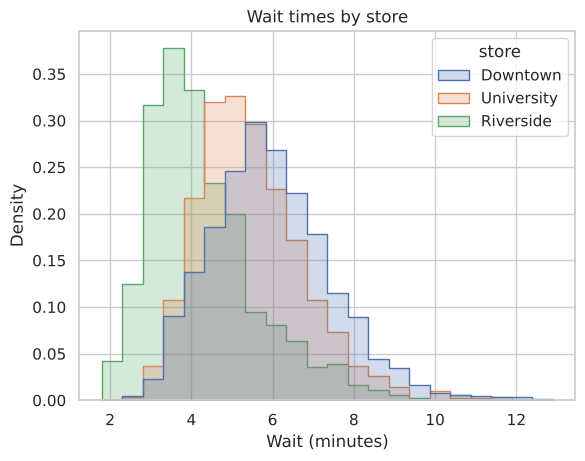

In [7]:
store_order = ["Downtown", "University", "Riverside"]

sns.histplot(data=orders, x="wait_min", hue="store",
             hue_order=store_order, binwidth=0.5,
             element="step", stat="density", common_norm=False)
plt.title("Wait times by store")
plt.xlabel("Wait (minutes)")
plt.savefig(FIG / "ch12-hist-wait-store.png", dpi=150, bbox_inches="tight")
plt.show()

### Density curves

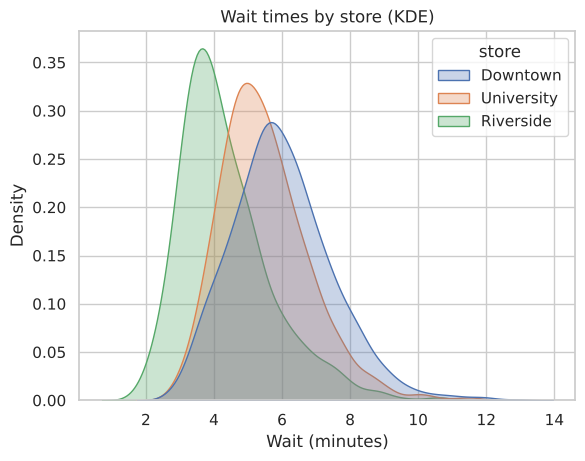

In [8]:
sns.kdeplot(data=orders, x="wait_min", hue="store",
            hue_order=store_order, fill=True, common_norm=False,
            alpha=0.3)
plt.title("Wait times by store (KDE)")
plt.xlabel("Wait (minutes)")
plt.savefig(FIG / "ch12-kde-wait-store.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
orders.groupby("store")["wait_min"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
store,,,,,,,,
Downtown,1308.0,6.0,1.5,2.8,5.0,5.9,6.9,12.9
Riverside,714.0,4.3,1.4,1.8,3.4,4.0,5.0,10.7
University,978.0,5.5,1.3,2.7,4.6,5.3,6.2,11.6


### Figure-level `displot` with facets

`col=` makes one panel per value. Figure-level functions return a grid object `g`.

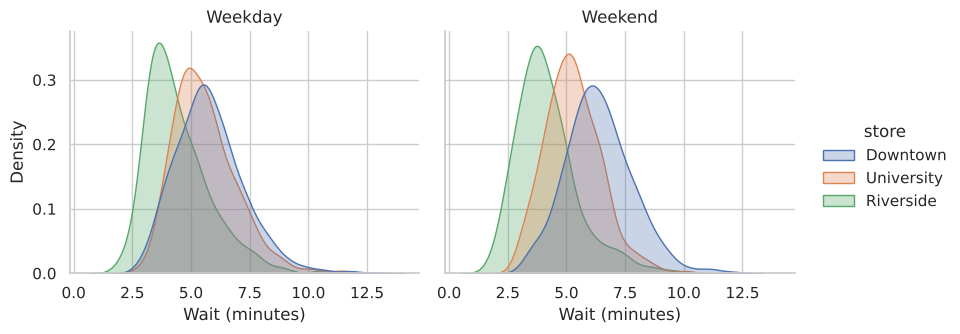

In [10]:
g = sns.displot(data=orders, x="wait_min", hue="store",
                hue_order=store_order, col="day_type", kind="kde",
                fill=True, common_norm=False, alpha=0.3,
                height=3.5, aspect=1.2)
g.set_axis_labels("Wait (minutes)", "Density")
g.set_titles("{col_name}")
plt.savefig(FIG / "ch12-displot-daytype.png", dpi=150, bbox_inches="tight")
plt.show()

## 12.4 Categorical plots

### Counting with `countplot`

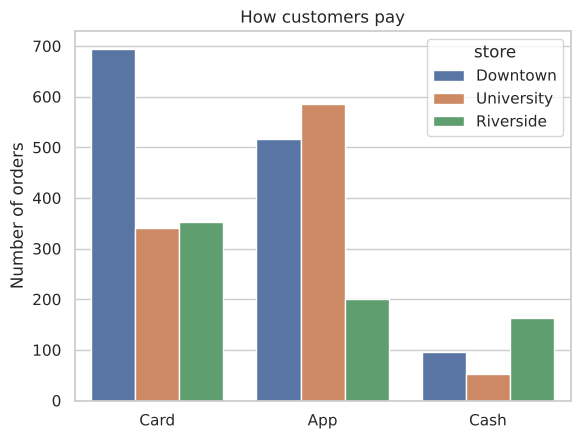

In [11]:
sns.countplot(data=orders, x="payment", hue="store",
              order=["Card", "App", "Cash"], hue_order=store_order)
plt.title("How customers pay")
plt.xlabel("")
plt.ylabel("Number of orders")
plt.savefig(FIG / "ch12-count-payment.png", dpi=150, bbox_inches="tight")
plt.show()

### Averages with `barplot`

Bars show the mean; the black line is a 95% confidence interval.

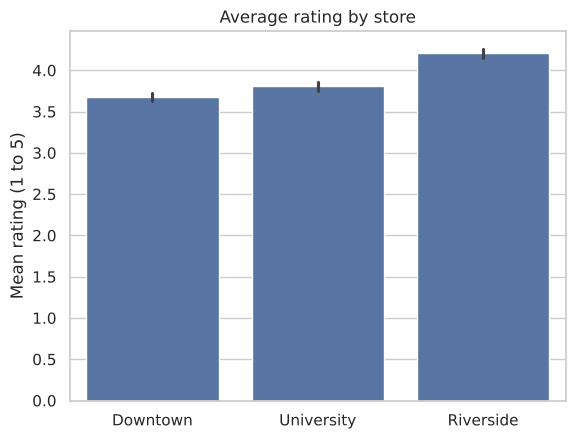

In [12]:
sns.barplot(data=orders, x="store", y="rating", order=store_order)
plt.title("Average rating by store")
plt.xlabel("")
plt.ylabel("Mean rating (1 to 5)")
plt.savefig(FIG / "ch12-bar-rating.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
orders.groupby("store")["rating"].agg(["mean", "count"]).round(2)

,mean,count
store,,
Downtown,3.67,1308
Riverside,4.21,714
University,3.80,978


### Spread with `boxplot`

Line = median, box = middle 50%, whiskers = up to 1.5 × IQR, dots = possible outliers.

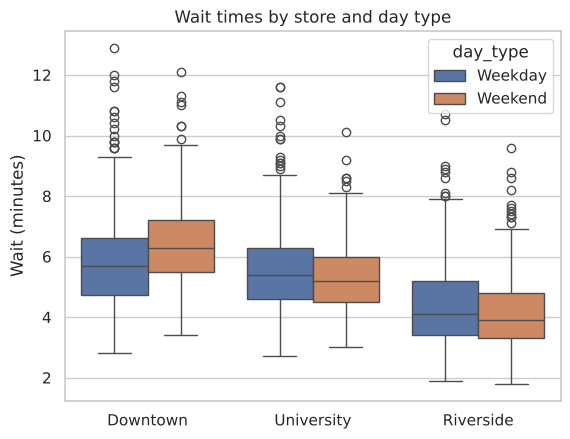

In [14]:
sns.boxplot(data=orders, x="store", y="wait_min", hue="day_type",
            order=store_order)
plt.title("Wait times by store and day type")
plt.xlabel("")
plt.ylabel("Wait (minutes)")
plt.savefig(FIG / "ch12-box-wait.png", dpi=150, bbox_inches="tight")
plt.show()

### Violins and strips

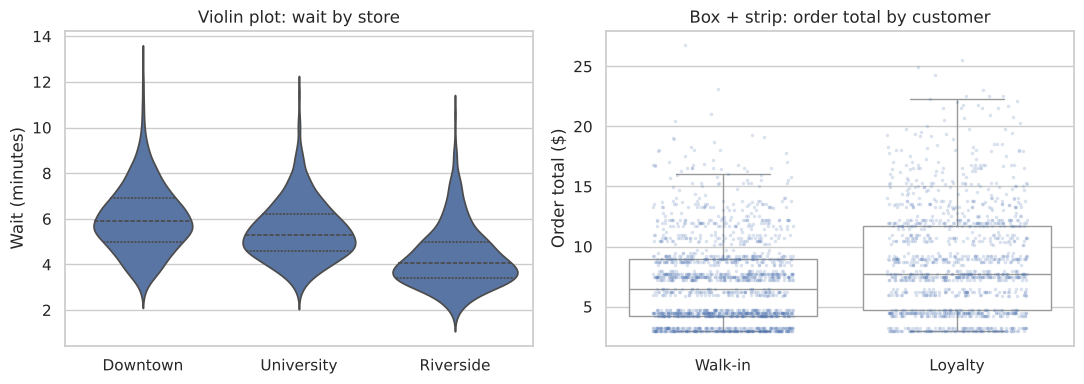

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.violinplot(data=orders, x="store", y="wait_min", order=store_order,
               inner="quartile", ax=axes[0])
axes[0].set(title="Violin plot: wait by store", xlabel="",
            ylabel="Wait (minutes)")

sns.boxplot(data=orders, x="customer", y="order_total",
            showfliers=False, color="white", ax=axes[1])
sns.stripplot(data=orders, x="customer", y="order_total",
              alpha=0.2, size=2.5, jitter=0.3, ax=axes[1])
axes[1].set(title="Box + strip: order total by customer", xlabel="",
            ylabel="Order total ($)")

plt.tight_layout()
plt.savefig(FIG / "ch12-violin-strip.png", dpi=150, bbox_inches="tight")
plt.show()

### Facets with `catplot`

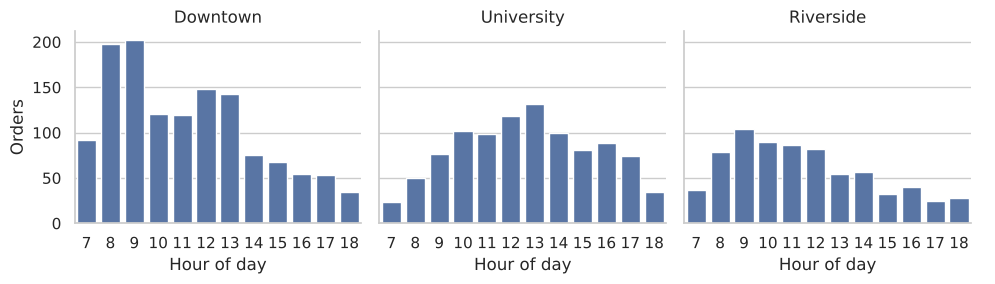

In [16]:
g = sns.catplot(data=orders, x="hour", col="store", col_order=store_order,
                kind="count", color="#4C72B0", height=3, aspect=1.1)
g.set_axis_labels("Hour of day", "Orders")
g.set_titles("{col_name}")
plt.savefig(FIG / "ch12-catplot-hours.png", dpi=150, bbox_inches="tight")
plt.show()

## 12.5 Relationships

`lineplot` averages repeated y values and shades a confidence band. `y_jitter` only moves the dots for display.

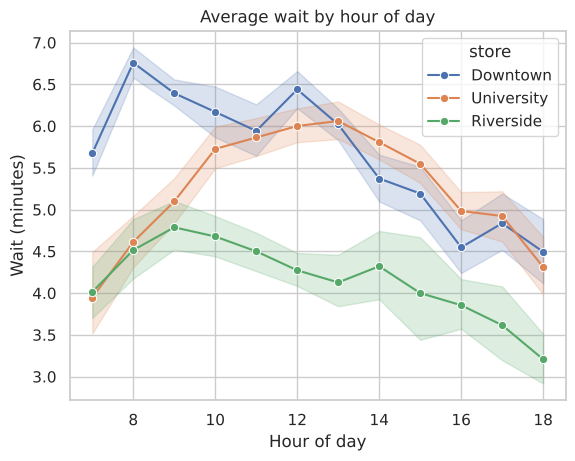

In [17]:
sns.lineplot(data=orders, x="hour", y="wait_min", hue="store",
             hue_order=store_order, marker="o")
plt.title("Average wait by hour of day")
plt.xlabel("Hour of day")
plt.ylabel("Wait (minutes)")
plt.savefig(FIG / "ch12-line-wait-hour.png", dpi=150, bbox_inches="tight")
plt.show()

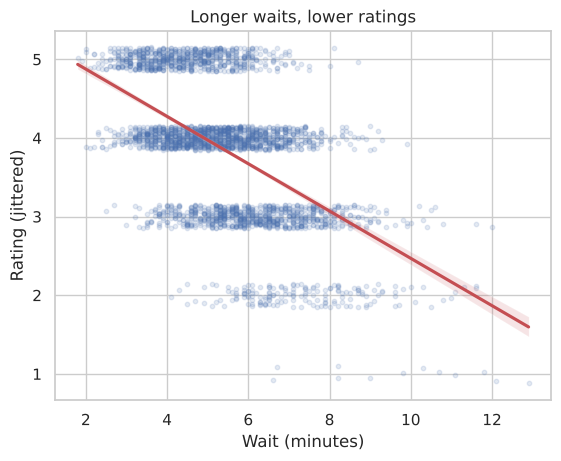

In [18]:
sns.regplot(data=orders, x="wait_min", y="rating", y_jitter=0.15,
            scatter_kws={"alpha": 0.15, "s": 10},
            line_kws={"color": "#C44E52"})
plt.title("Longer waits, lower ratings")
plt.xlabel("Wait (minutes)")
plt.ylabel("Rating (jittered)")
plt.savefig(FIG / "ch12-reg-wait-rating.png", dpi=150, bbox_inches="tight")
plt.show()

## 12.6 Heatmaps

Sequential colormap (`Blues`) for low-to-high values; diverging colormap (`vlag`) centered at 0 for correlations.

In [19]:
revenue = sales.pivot_table(index="product", columns="store",
                            values="revenue", aggfunc="sum")
revenue = revenue[store_order]
revenue

store,Downtown,University,Riverside
product,,,
Blueberry Muffin,6339.55,4534.15,3660.95
Cappuccino,13493.75,9855.75,7654.25
Cold Brew,12464.00,9129.50,7106.00
Croissant,9145.50,6747.00,5557.50
Espresso,7734.00,5517.00,4464.00
Latte,21028.50,14787.00,11695.50


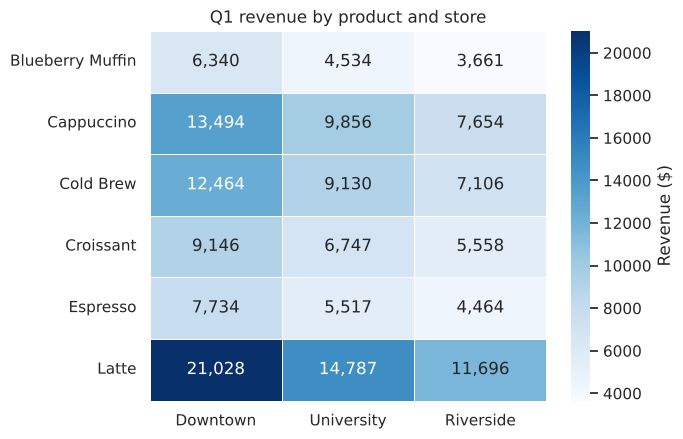

In [20]:
sns.heatmap(revenue, annot=True, fmt=",.0f", cmap="Blues",
            linewidths=0.5, cbar_kws={"label": "Revenue ($)"})
plt.title("Q1 revenue by product and store")
plt.xlabel("")
plt.ylabel("")
plt.savefig(FIG / "ch12-heatmap-revenue.png", dpi=150, bbox_inches="tight")
plt.show()

In [21]:
numeric = ["hour", "items", "order_total", "wait_min", "rating"]
corr = orders[numeric].corr()
corr.round(2)

,hour,items,order_total,wait_min,rating
hour,1.00,0.01,0.02,-0.20,0.10
items,0.01,1.00,0.97,0.17,-0.09
order_total,0.02,0.97,1.00,0.17,-0.08
wait_min,-0.20,0.17,0.17,1.00,-0.54
rating,0.10,-0.09,-0.08,-0.54,1.00


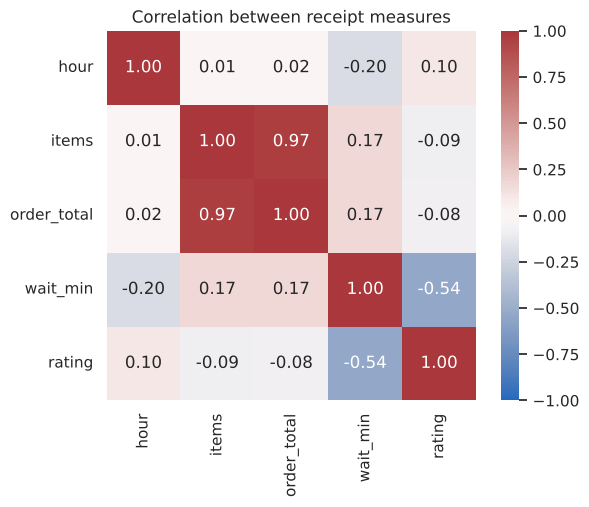

In [22]:
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag",
            vmin=-1, vmax=1, center=0, square=True)
plt.title("Correlation between receipt measures")
plt.savefig(FIG / "ch12-heatmap-corr.png", dpi=150, bbox_inches="tight")
plt.show()

## 12.7 Pair plots

One scatter plot per pair of columns; keep `vars` to a handful.

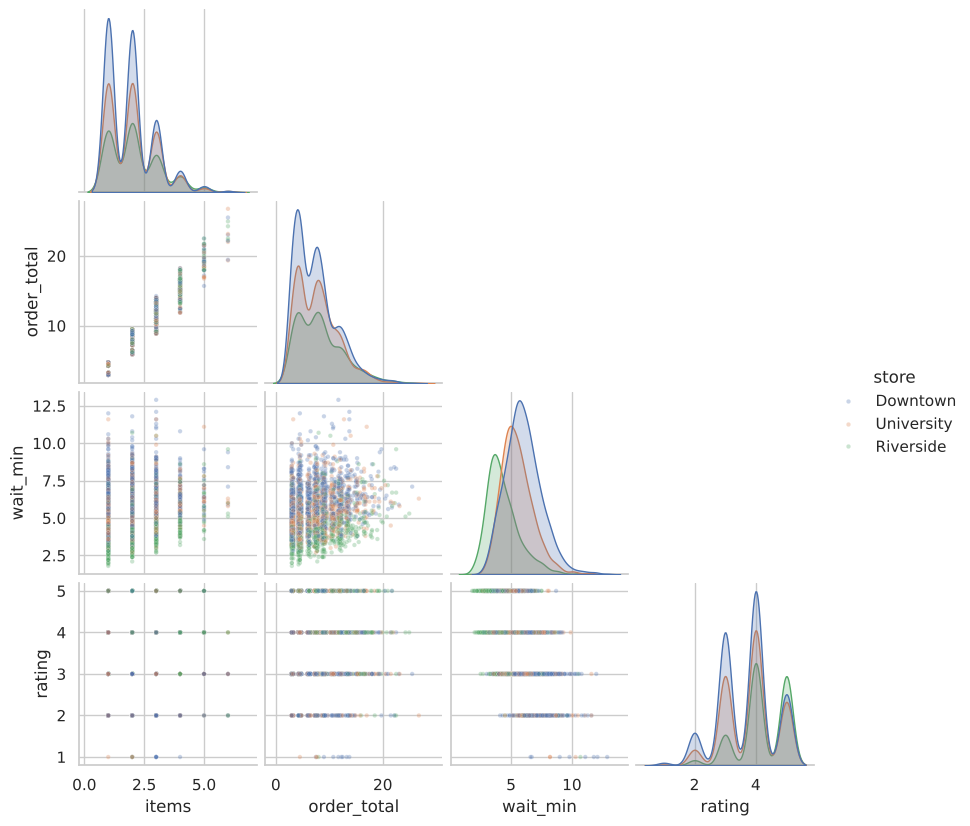

In [23]:
g = sns.pairplot(orders, vars=["items", "order_total", "wait_min",
                               "rating"],
                 hue="store", hue_order=store_order, corner=True,
                 height=2.1, plot_kws={"alpha": 0.3, "s": 10})
plt.savefig(FIG / "ch12-pairplot.png", dpi=150, bbox_inches="tight")
plt.show()

## 12.8 Styling, combining and saving

Pass `ax=` to draw Seaborn charts on your own Matplotlib axes. Bars start at zero.

In [24]:
sns.color_palette("deep").as_hex()

['#4c72b0',
 '#dd8452',
 '#55a868',
 '#c44e52',
 '#8172b3',
 '#937860',
 '#da8bc3',
 '#8c8c8c',
 '#ccb974',
 '#64b5cd']

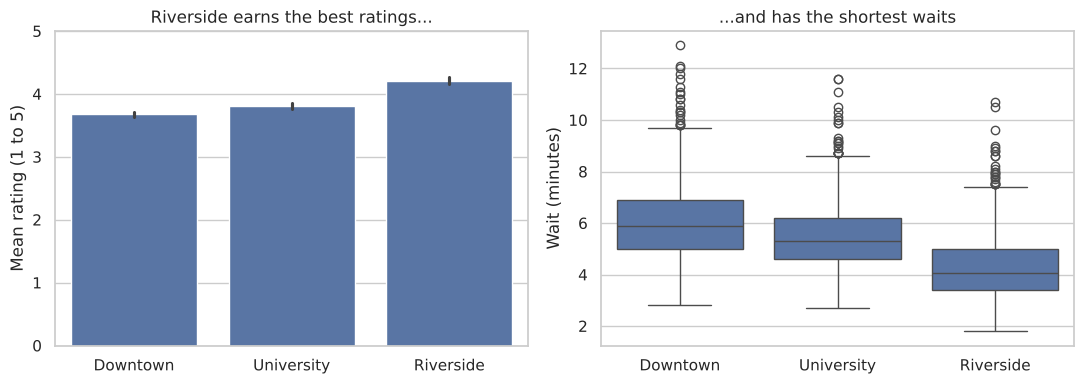

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=orders, x="store", y="rating", order=store_order,
            color="#4C72B0", ax=axes[0])
axes[0].set(title="Riverside earns the best ratings...", xlabel="",
            ylabel="Mean rating (1 to 5)", ylim=(0, 5))

sns.boxplot(data=orders, x="store", y="wait_min", order=store_order,
            color="#4C72B0", ax=axes[1])
axes[1].set(title="...and has the shortest waits", xlabel="",
            ylabel="Wait (minutes)")

fig.tight_layout()
fig.savefig("../figures/ch12-store-summary.png", dpi=150,
            bbox_inches="tight")
plt.show()

## Exercises

Solutions are in Appendix D of the book.

1. Draw a histogram of `items` (items per order) with `discrete=True`. What
   is the most common basket size?
2. Use `sns.boxplot` to compare `order_total` for Loyalty and Walk-in
   customers at each store (put `store` on the x-axis and use
   `hue="customer"`). Do loyalty members spend more at every store?
3. Make a heatmap of the number of orders by `hour` (rows) and `store`
   (columns). *Hint:* `pd.crosstab(orders["hour"], orders["store"])`.
4. With the sales data, use `sns.barplot` with `estimator="sum"` to show
   total quantity by product, sorted from best to worst seller.
5. Compute daily revenue per store from `sales` and draw it with
   `sns.lineplot`. Then try `sns.relplot(..., kind="line", col="store")`.
6. Draw a pair plot of `items`, `order_total` and `wait_min` coloured by
   `customer`. Which pair of variables is almost a straight line, and why?
7. **Think about it:** In the correlation heatmap, `hour` and `wait_min`
   have a correlation of about -0.2. Does that mean waits get steadily
   shorter through the day? Check with the line chart from 12.5.